In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import scipy
from tqdm import tqdm   

### Gerchberg-Saxton Algorithm

Gaussian input and target

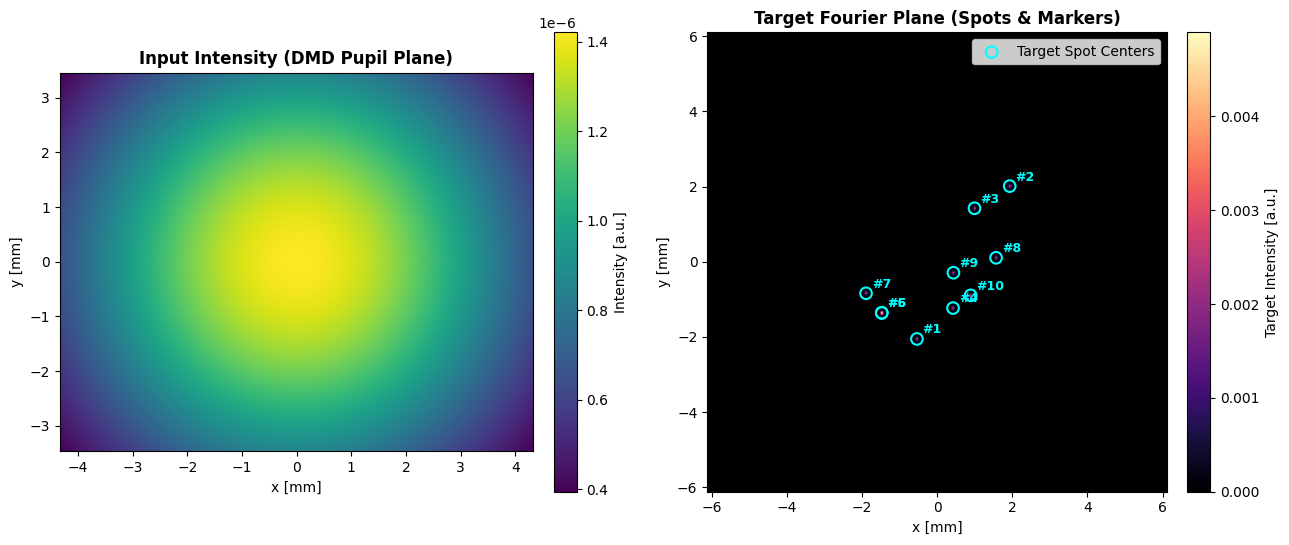

In [ ]:
# --- System Parameters ---
N_x = 1140  # DMD resolution (columns)
N_y = 912  # DMD resolution (rows)
pitch = 7.6e-6  # Pixel pitch [m]

N_spots = 10
wavelength = 930e-9  # [m]
f = 0.1  # Lens focal length [m]

# --- Beam Waists ---
sigma_input = (N_y * pitch) / 2
sigma_target = (wavelength * f) / (4 * np.pi * sigma_input)

# --- Coordinate Grids ---
x = (np.arange(N_x) - N_x / 2) * pitch
y = (np.arange(N_y) - N_y / 2) * pitch
X, Y = np.meshgrid(x, y)

fx = (np.arange(N_x) - N_x / 2) * (wavelength * f / (N_x * pitch))
fy = (np.arange(N_y) - N_y / 2) * (wavelength * f / (N_y * pitch))
fX, fY = np.meshgrid(fx, fy)

span_fx = wavelength * f / pitch
span_fy = wavelength * f / pitch

# --- Input Intensity (Pupil Plane) ---
input_intensity = np.exp(-(X**2 + Y**2) / (2 * sigma_input**2))
input_intensity /= np.sum(input_intensity)

# --- Spot Target Generation (Fourier Plane) ---
np.random.seed(42)
positions_x = np.random.uniform(-0.35, 0.35, size=N_spots) * (span_fx / 2)
positions_y = np.random.uniform(-0.35, 0.35, size=N_spots) * (span_fy / 2)

# Single-pixel delta targets for strict GS computation
target_intensity = np.zeros((N_y, N_x))
for x_spot, y_spot in zip(positions_x, positions_y):
    idx_x = np.argmin(np.abs(fx - x_spot))
    idx_y = np.argmin(np.abs(fy - y_spot))
    target_intensity[idx_y, idx_x] = 1.0

target_intensity *= np.sum(input_intensity) / np.sum(target_intensity)

# Slight Gaussian blur applied ONLY for display purposes
vis_target_intensity = gaussian_filter(target_intensity, sigma=2.5)


# --- Plotting Function ---
def plot_input_and_target(
    input_intensity, target_intensity_vis, positions_x, positions_y, x, y, fx, fy
):
    fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))

    # Panel 1: Input Beam Profile
    im0 = axs[0].imshow(
        input_intensity,
        extent=[x[0] * 1e3, x[-1] * 1e3, y[0] * 1e3, y[-1] * 1e3],
        origin="lower",
        cmap="viridis",
    )
    axs[0].set_title("Input Intensity (DMD Pupil Plane)", fontsize=12, fontweight="bold")
    axs[0].set_xlabel("x [mm]")
    axs[0].set_ylabel("y [mm]")
    fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04, label="Intensity [a.u.]")

    # Panel 2: Target Fourier Spots with Overlay Markers
    im1 = axs[1].imshow(
        target_intensity_vis,
        extent=[fx[0] * 1e3, fx[-1] * 1e3, fy[0] * 1e3, fy[-1] * 1e3],
        origin="lower",
        cmap="magma",
    )
    axs[1].set_title("Target Fourier Plane (Spots & Markers)", fontsize=12, fontweight="bold")
    axs[1].set_xlabel("x [mm]")
    axs[1].set_ylabel("y [mm]")
    fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04, label="Target Intensity [a.u.]")

    # Overlay cyan circle markers & index tags on spot positions
    axs[1].scatter(
        positions_x * 1e3,
        positions_y * 1e3,
        color="cyan",
        s=70,
        facecolors="none",
        edgecolors="cyan",
        linewidths=1.5,
        label="Target Spot Centers",
    )

    for idx, (px, py) in enumerate(zip(positions_x, positions_y)):
        axs[1].text(
            px * 1e3 + 0.15,
            py * 1e3 + 0.15,
            f"#{idx+1}",
            color="cyan",
            fontsize=9,
            weight="bold",
        )

    axs[1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()


plot_input_and_target(
    input_intensity, vis_target_intensity, positions_x, positions_y, x, y, fx, fy
)

  0%|          | 0/41 [00:00<?, ?it/s]C:\Users\timmerman\AppData\Local\Temp\ipykernel_12892\1420595670.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


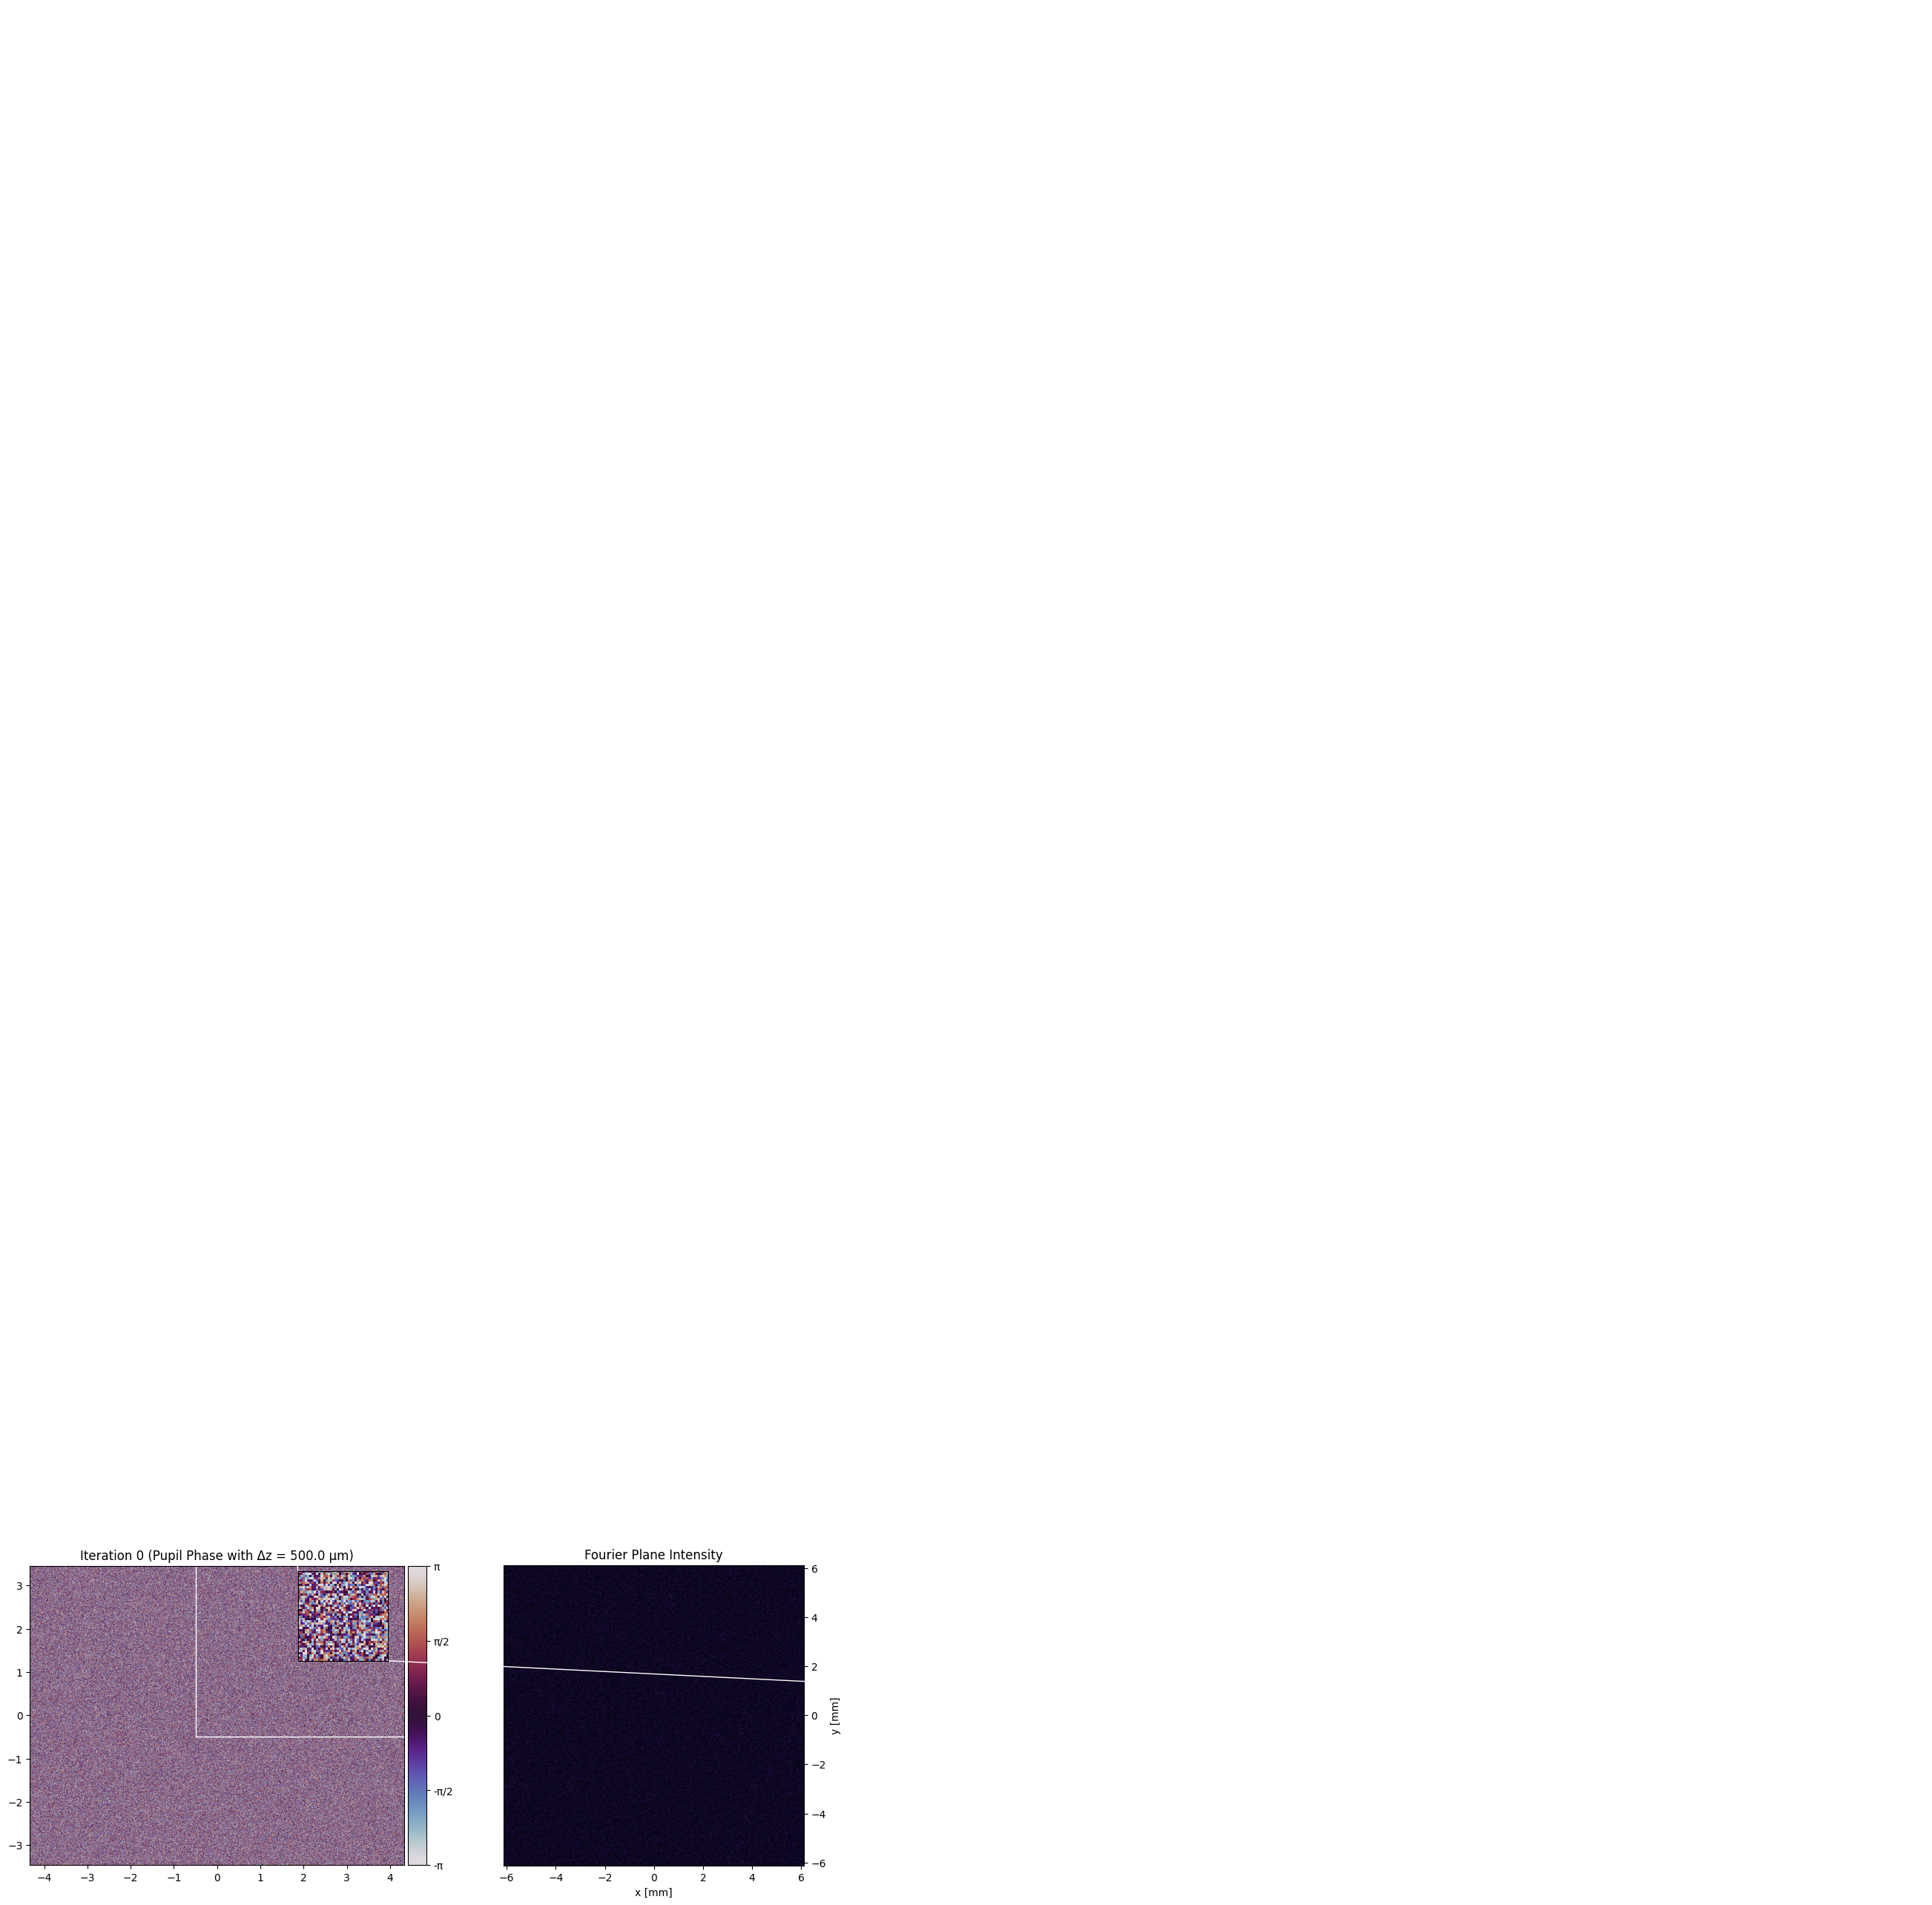

 24%|██▍       | 10/41 [00:04<00:10,  3.05it/s]C:\Users\timmerman\AppData\Local\Temp\ipykernel_12892\1420595670.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


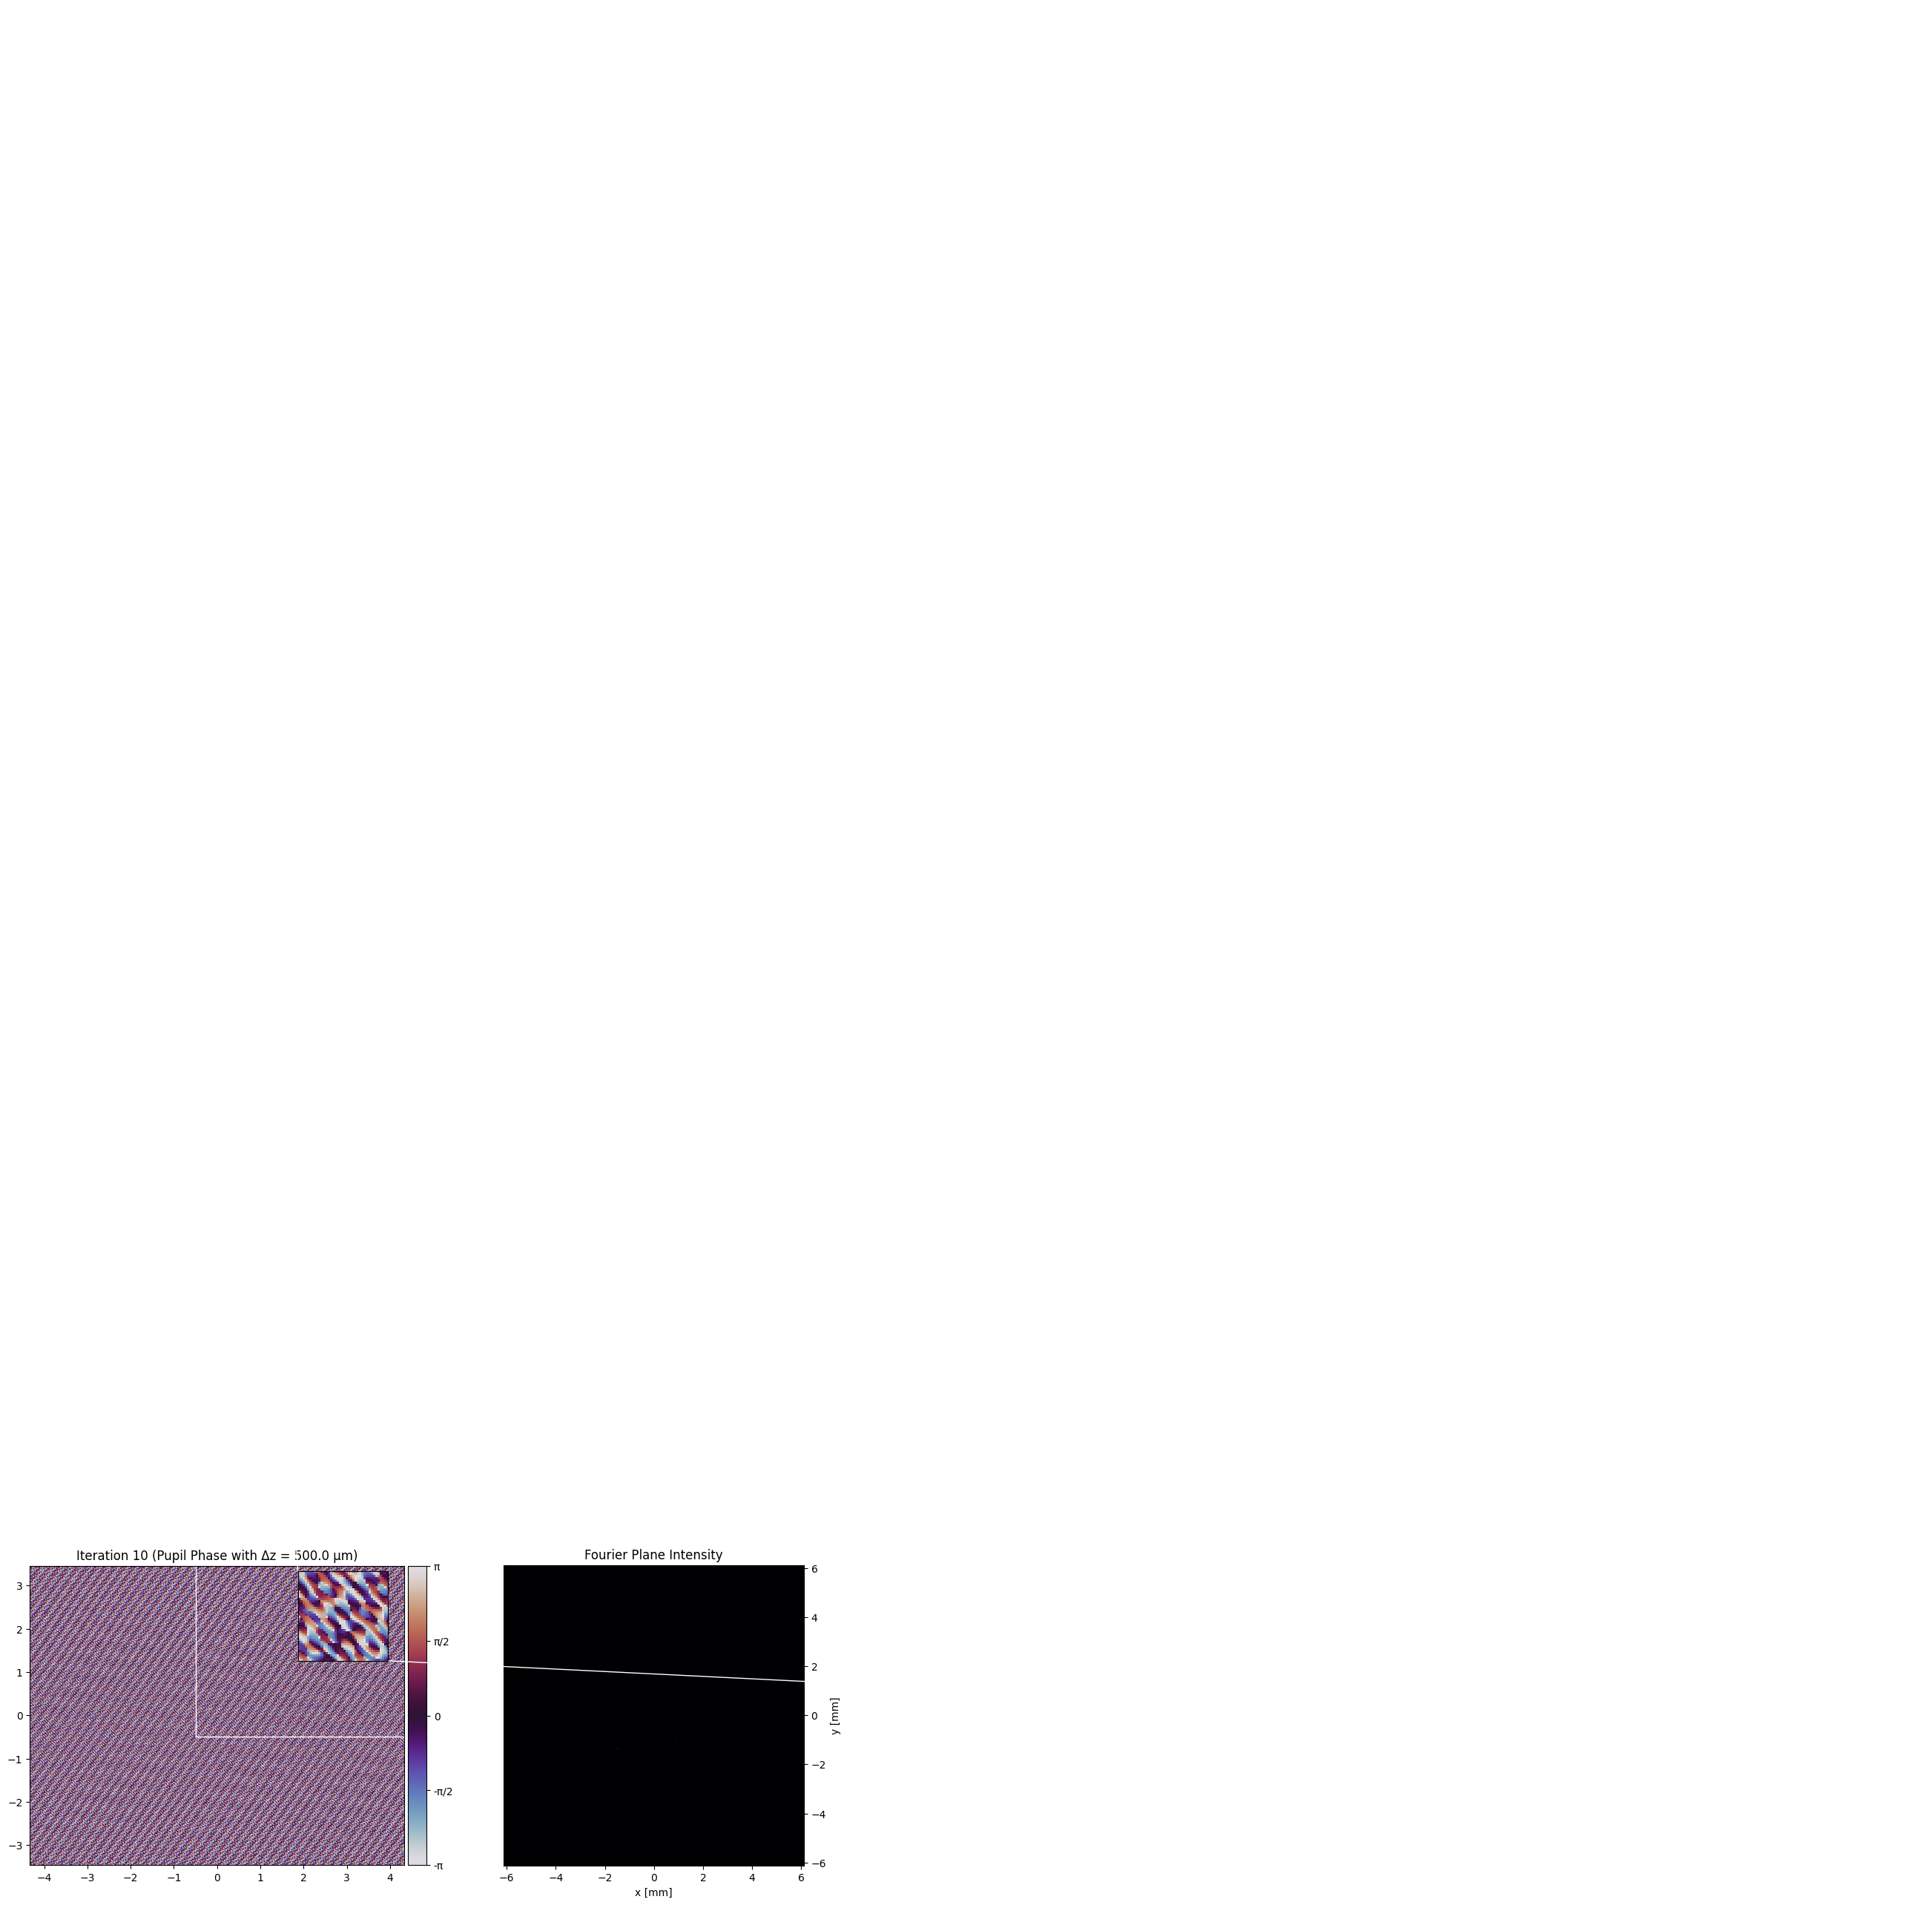

 49%|████▉     | 20/41 [00:08<00:06,  3.07it/s]C:\Users\timmerman\AppData\Local\Temp\ipykernel_12892\1420595670.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


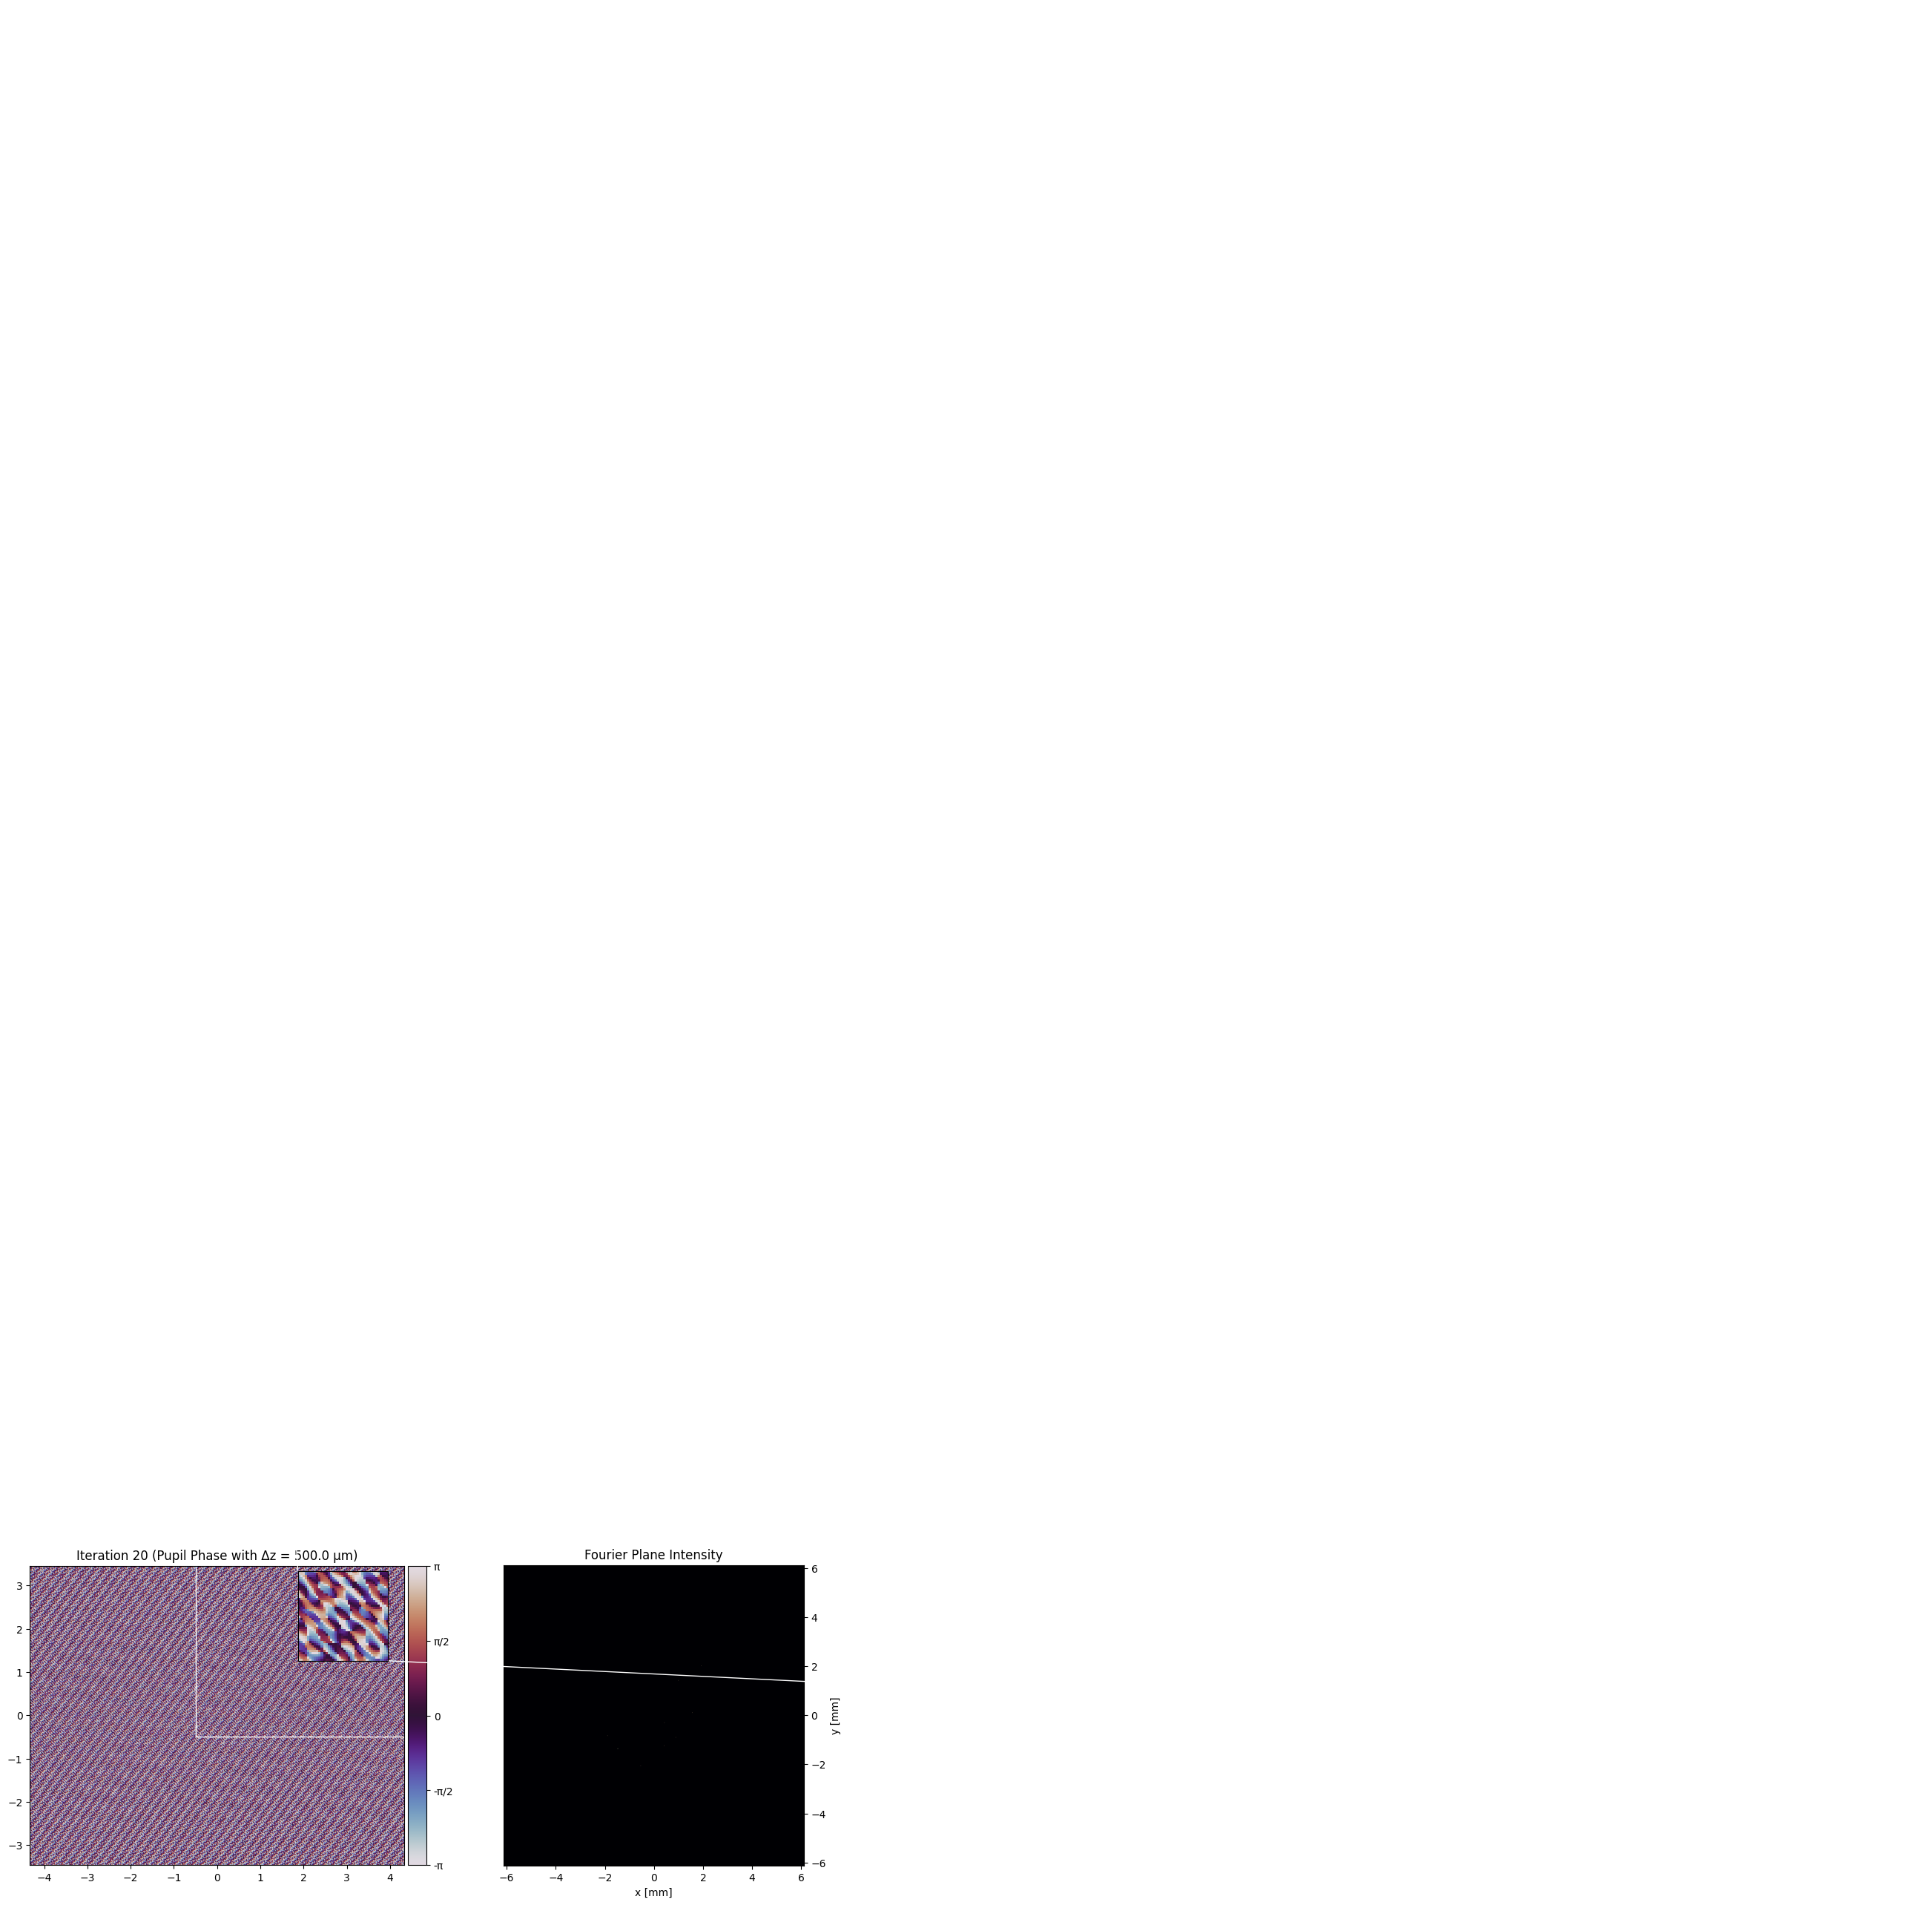

 73%|███████▎  | 30/41 [00:12<00:03,  3.29it/s]C:\Users\timmerman\AppData\Local\Temp\ipykernel_12892\1420595670.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


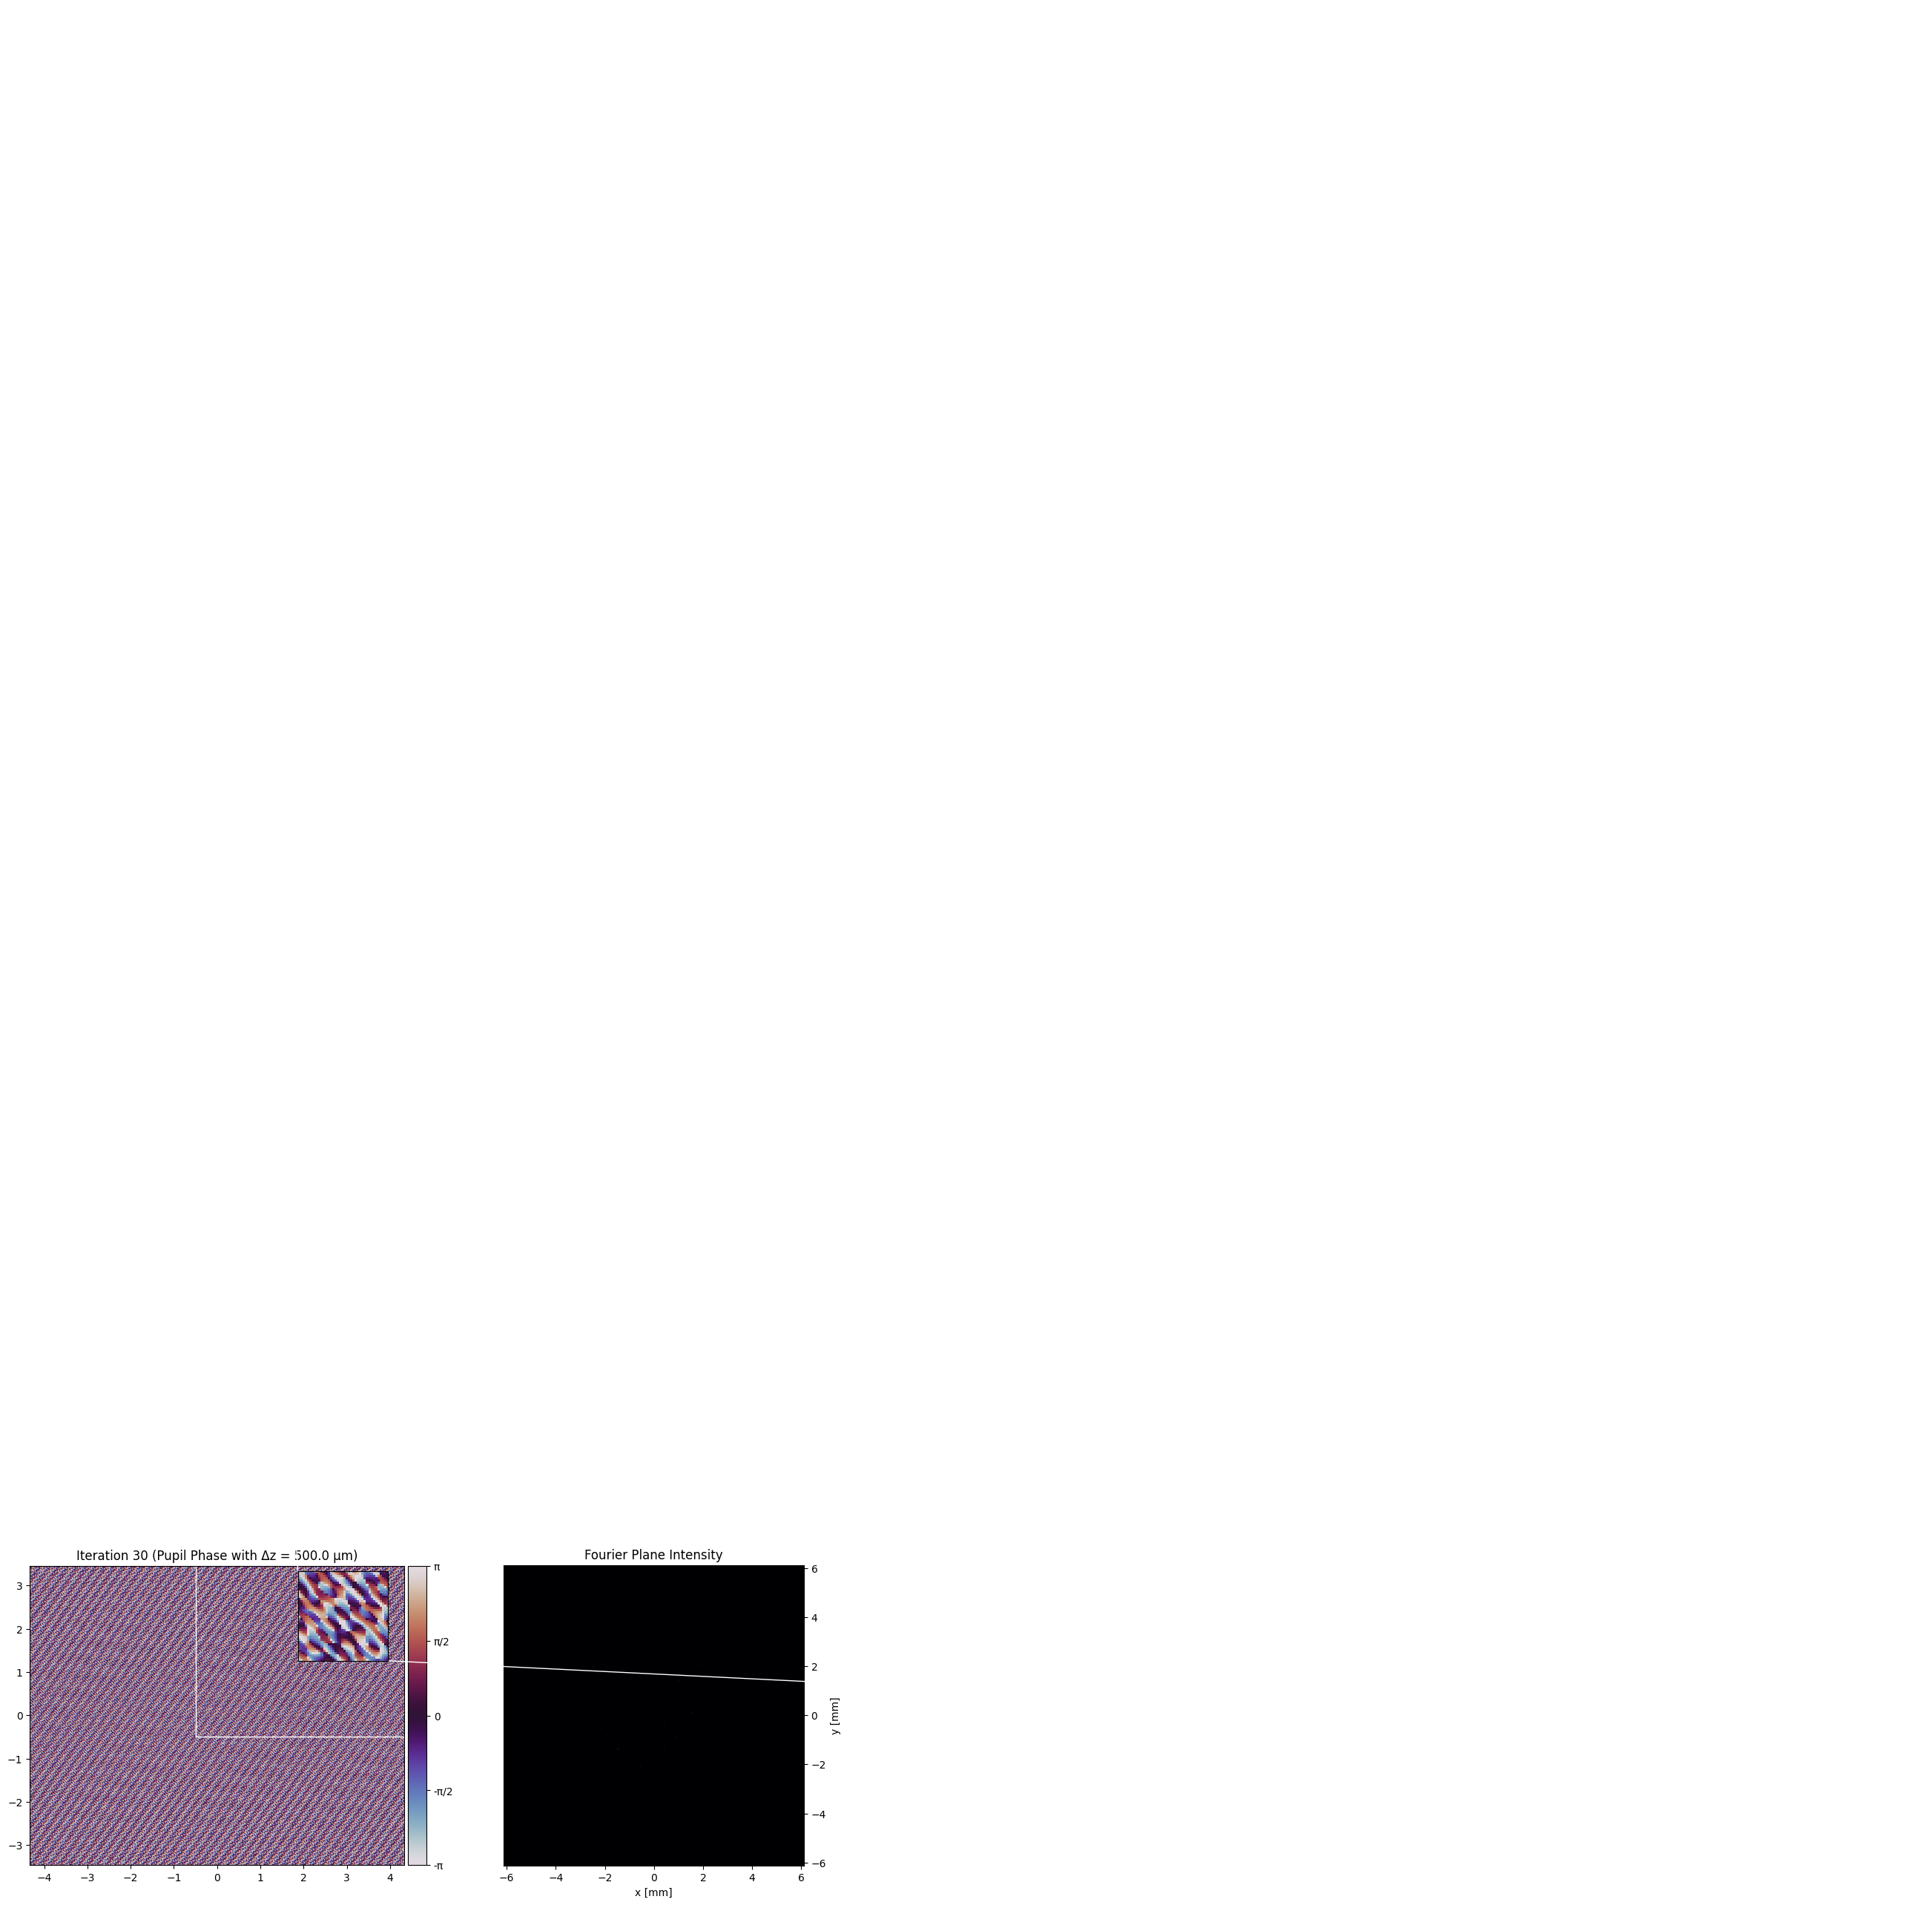

 98%|█████████▊| 40/41 [00:16<00:00,  3.22it/s]C:\Users\timmerman\AppData\Local\Temp\ipykernel_12892\1420595670.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


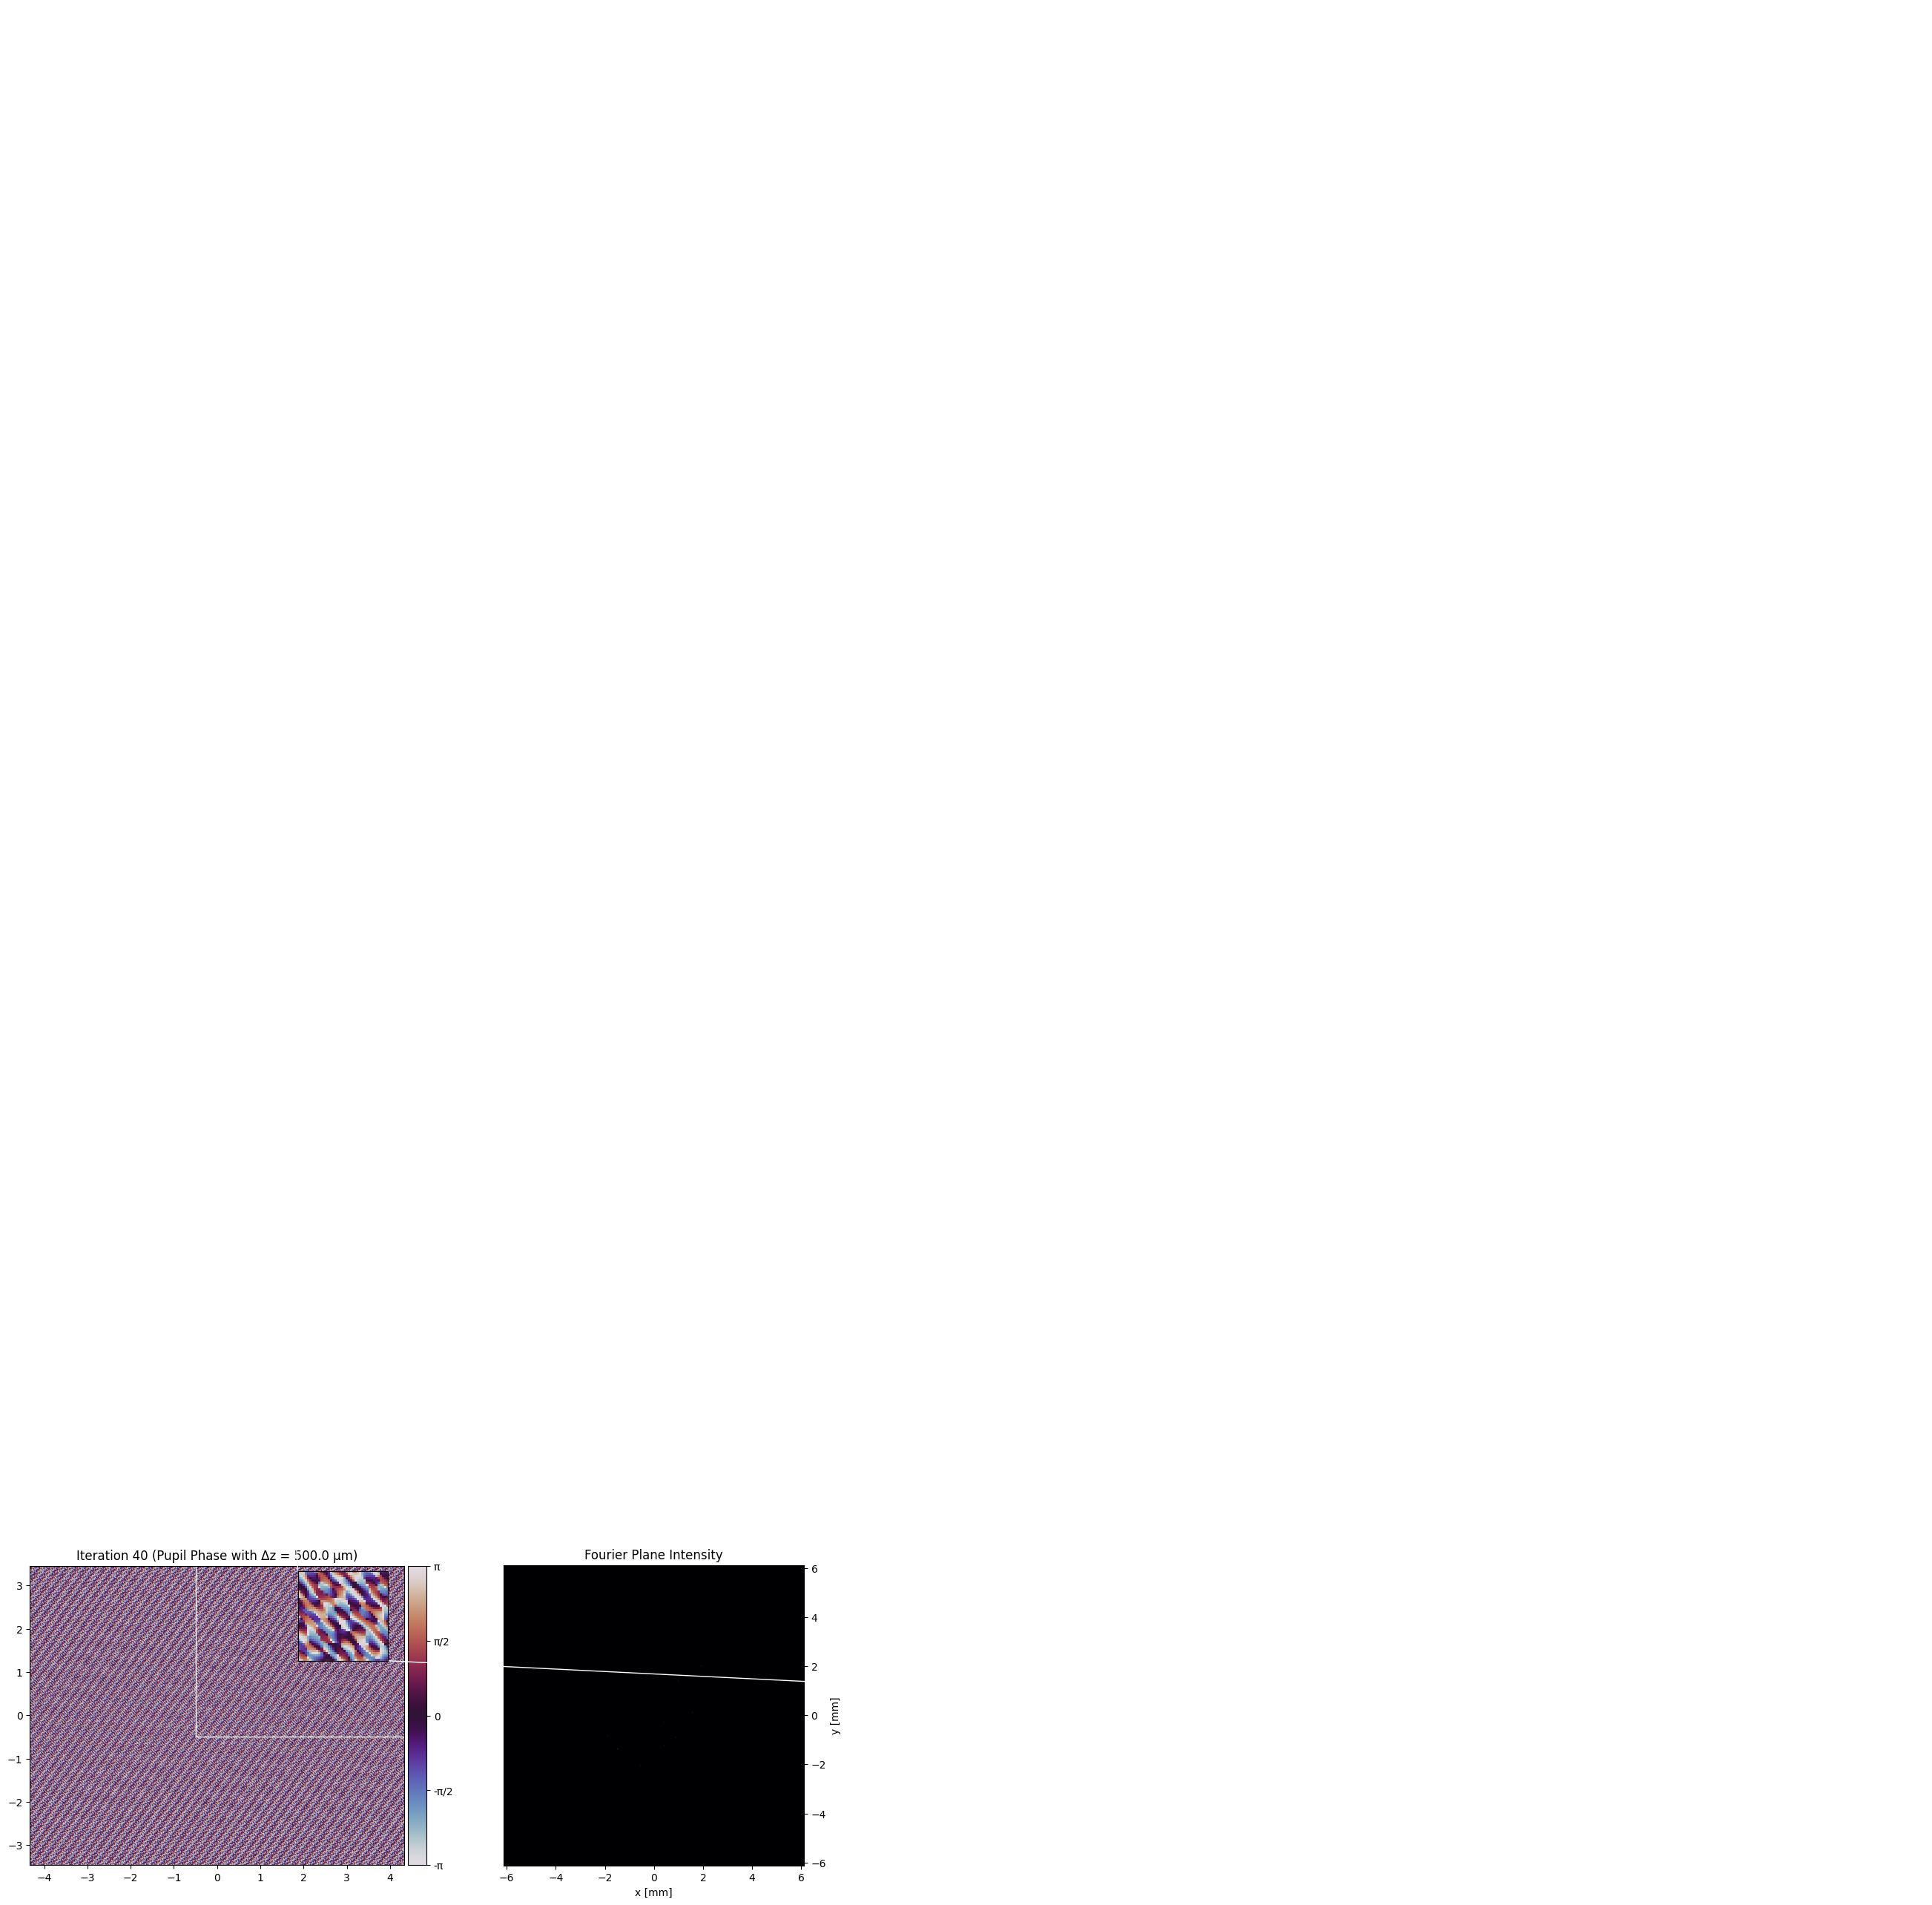

100%|██████████| 41/41 [00:17<00:00,  2.37it/s]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from tqdm import tqdm

# --- Coordinate Grids for Phase Calculation ---
# Physical pupil coordinates (N_y, N_x)
x = (np.arange(N_x) - N_x / 2) * pitch
y = (np.arange(N_y) - N_y / 2) * pitch
X, Y = np.meshgrid(x, y)


def compute_defocus_phase(
    X: np.ndarray,
    Y: np.ndarray,
    wavelength: float,
    f_lens: float,
    delta_z: float = 0.0,
    f_defocus: float = None,
) -> np.ndarray:
    """Calculates quadratic defocus phase profile at the pupil plane.

    Provide EITHER delta_z (axial defocus distance [m]) OR f_defocus (focal
    length of DMD digital lens [m]).
    """
    if f_defocus is None and delta_z != 0.0:
        # Thin lens relation: 1/f_defocus ≈ delta_z / (f_lens^2)
        f_defocus = (f_lens**2) / delta_z

    if f_defocus is None or np.isinf(f_defocus):
        return np.zeros_like(X)

    # Quadratic phase: phi = (pi / (lambda * f_d)) * (X^2 + Y^2)
    phi_defocus = (np.pi / (wavelength * f_defocus)) * (X**2 + Y**2)
    return phi_defocus


def Gerchberg_Saxton(
    input_amp: np.ndarray,
    target_amp: np.ndarray,
    initial_phase: np.ndarray,
    wavelength: float = 930e-9,
    f_lens: float = 0.1,
    delta_z: float = 0.0,  # Axial defocus shift [m]
    N_iterations: int = 1000,
    plot_every: int = 100,
) -> np.ndarray:

    # 1. Compute quadratic defocus phase factor
    phi_defocus = compute_defocus_phase(
        X, Y, wavelength=wavelength, f_lens=f_lens, delta_z=delta_z
    )

    # Base initial phase loop variable
    phase_beam = initial_phase

    for i in tqdm(range(N_iterations + 1)):
        # Apply total phase (GS phase + defocus phase) at pupil
        total_pupil_phase = phase_beam + phi_defocus
        field_beam = input_amp * np.exp(1j * total_pupil_phase)

        # Forward propagation to Fourier plane
        field_focus = np.fft.fftshift(np.fft.fft2(field_beam))
        phase_focus = np.angle(field_focus)

        if i % plot_every == 0 or i == N_iterations:
            fig, axs = plt.subplots(1, 2, figsize=(3, 4))

            # Wrapped total phase for display [-pi, pi]
            displayed_phase = np.angle(np.exp(1j * total_pupil_phase))

            phase_ticks = [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
            phase_tick_names = ["-π", "-π/2", "0", "π/2", "π"]

            # Panel 0: DMD Pupil Phase
            axs[0].set_title(
                f"Iteration {i} (Pupil Phase with Δz = {delta_z*1e6:.1f} µm)"
            )
            im_phase = axs[0].imshow(
                displayed_phase,
                extent=[x[0] * 1e3, x[-1] * 1e3, y[0] * 1e3, y[-1] * 1e3],
                origin="lower",
                cmap="twilight",
            )
            divider = make_axes_locatable(axs[0])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cbar = fig.colorbar(im_phase, cax=cax)
            cbar.set_ticks(phase_ticks)
            cbar.set_ticklabels(phase_tick_names)

            # Inset zoom-in to inspect high-frequency fringes
            cx, cy = N_x // 2, N_y // 2
            axins = inset_axes(
                axs[0], width="30%", height="30%", loc="upper right"
            )
            axins.imshow(
                displayed_phase[cy - 20 : cy + 20, cx - 20 : cx + 20],
                cmap="twilight",
                origin="lower",
            )
            axins.set_xticks([])
            axins.set_yticks([])
            mark_inset(axs[0], axins, loc1=2, loc2=4, fc="none", ec="white")

            # Panel 1: Focused Target Intensity
            axs[1].set_title("Fourier Plane Intensity")
            im_int = axs[1].imshow(
                np.abs(field_focus) ** 2,
                extent=[fx[0] * 1e3, fx[-1] * 1e3, fy[0] * 1e3, fy[-1] * 1e3],
                origin="lower",
                cmap="magma",
            )
            axs[1].set_xlabel("x [mm]")
            axs[1].set_ylabel("y [mm]")
            axs[1].yaxis.tick_right()
            axs[1].yaxis.set_label_position("right")

            plt.tight_layout()
            plt.show()

        # Target intensity substitution
        field_focus = target_amp * np.exp(1j * phase_focus)

        # Backward propagation back to pupil plane
        field_beam = np.fft.ifft2(np.fft.ifftshift(field_focus))

        # Subtract defocus phase when extracting base GS phase solution
        phase_beam = np.angle(field_beam) - phi_defocus

    # Return total combined phase to write to DMD
    return np.angle(np.exp(1j * (phase_beam + phi_defocus)))


# --- Run Execution Example ---
initial_phase = (np.random.rand(N_y, N_x) * 2 - 1) * np.pi

# Example: Shift focus axially by delta_z = +500 micrometers
phasemask = Gerchberg_Saxton(
    input_amp=np.sqrt(input_intensity),
    target_amp=np.sqrt(target_intensity),
    initial_phase=initial_phase,
    wavelength=930e-9,
    f_lens=0.1,
    delta_z=500e-6,  # 500 µm axial defocus
    N_iterations=40,
    plot_every=10,
)

### Lee Holography

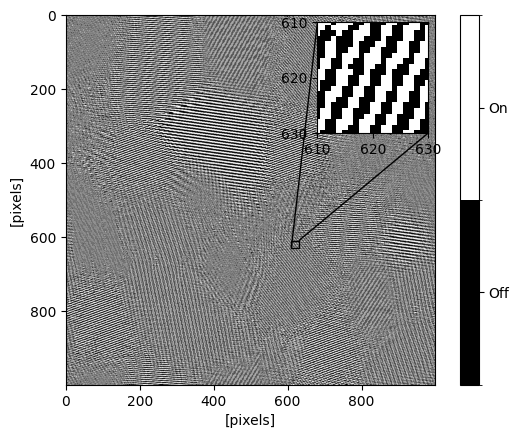

In [ ]:
carrier_period = 173 #pixels
carrier_freq = 2*np.pi / carrier_period / pitch #1/(carrier_period*dx)
fringes = (1 + np.cos(carrier_freq*(X+Y) - phasemask))/2

binary_fringes = np.zeros_like(fringes)
binary_fringes[fringes>1/2] = 1


cmap = ListedColormap(['black', 'white'])
norm = BoundaryNorm([0, 0.5, 1], cmap.N)
fig, ax = plt.subplots()
im = plt.imshow(binary_fringes, cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ticks=[0.25, 0.75])
cbar.set_ticklabels(['Off', 'On'])

ax.set_xlabel('[pixels]')
ax.set_ylabel('[pixels]')

x1, x2 = 610, 630
y1, y2 = x1, x2

axins = inset_axes(ax, width="30%", height="30%", loc="upper right")
axins.imshow(binary_fringes, cmap=cmap, norm=norm)
axins.set_xlim(x1, x2)
axins.set_ylim(y2, y1)
#axins.set_xticks([])
#axins.set_yticks([])

mark_inset(ax, axins, loc1=2, loc2=4)


plt.show()

### propagate beam after fringes

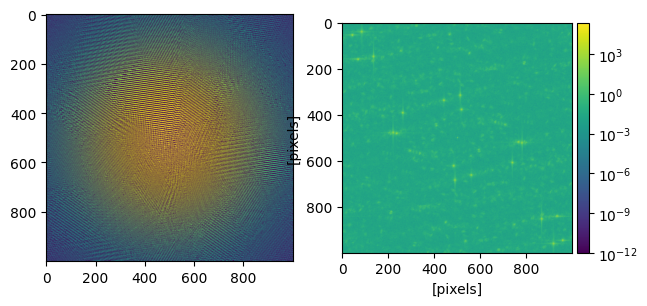

In [261]:
from matplotlib.colors import LogNorm

beam = input_intensity * binary_fringes



field_focus = np.fft.fftshift(np.fft.fft2(np.sqrt(beam)))

fig, axs = plt.subplots(1, 2, figsize=(7, 14))
axs[0].imshow(beam)
im = axs[1].imshow(np.abs(field_focus)**2, norm=LogNorm(vmin=1e-12))
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)
axs[1].set_xlabel('[pixels]')
axs[1].set_ylabel('[pixels]')
plt.show()

2.9510669286837242e-05 3.056944298558918e-05 0.499987442864442 0.49995247702328555


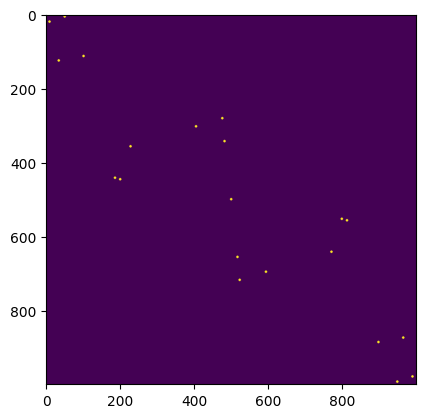

In [ ]:
r = 5*sigma_target*N_x/fieldsize_fplane

intensity_focus =  np.abs(field_focus)**2 / np.sum(np.abs(field_focus)**2)

mask_plus = np.zeros_like(field_focus)
mask_min = np.zeros_like(field_focus)
rows, cols = np.shape(field_focus)
Y, X = np.ogrid[:rows, :cols]

for (x, y) in positions:
    m, n = int(N_x/2 + x*N_x/fieldsize_fplane), int(N_x/2 + y*N_x/fieldsize_fplane)
    k, l = int(N_x/2 - x*N_x/fieldsize_fplane), int(N_x/2 - y*N_x/fieldsize_fplane)

    mask_plus += (X - m)**2 + (Y - n)**2 < r**2
    mask_min += (X - k)**2 + (Y - l)**2 < r**2
    
mask_plusorder = np.real(mask_plus) > 0
mask_minorder = np.real(mask_min) > 0
mask_zeroorder = (X - N_x//2)**2 + (Y - N_x//2)**2 < r**2
plt.imshow(mask_plusorder+mask_minorder+mask_zeroorder)

loss_plusorder = np.sum(intensity_focus[mask_plusorder])
loss_minorder = np.sum(intensity_focus[mask_minorder])
loss_zeroorder = np.sum(intensity_focus[mask_zeroorder])
otherloss = 1-loss_plusorder-loss_minorder-loss_zeroorder

print(loss_plusorder, loss_minorder, loss_zeroorder, otherloss)


In [ ]:
loss0 = []
loss1 = []
lossmin1 = []
lossother = []

periods = np.arange(2, N_x, .1)

for carrier_period in periods:     #pixels
    carrier_freq = 2*np.pi/carrier_period / pitch #1/(carrier_period*dx)
    fringes = (1 + np.cos(carrier_freq*(X+Y) - phasemask))/2

    binary_fringes = np.zeros_like(fringes)
    binary_fringes[fringes>1/2] = 1

    beam = input_intensity * binary_fringes
    field_focus = np.fft.fftshift(np.fft.fft2(np.sqrt(beam)))
    
    r = 5*sigma_target*N_x/fieldsize_fplane

    intensity_focus =  np.abs(field_focus)**2 / np.sum(np.abs(field_focus)**2)
    #plt.imshow(intensity_focus*(mask_plusorder+mask_plusorder+mask_plusorder))
    #plt.show()

    loss_plusorder = np.sum(intensity_focus[mask_plusorder])
    loss_minorder = np.sum(intensity_focus[mask_minorder])
    loss_zeroorder = np.sum(intensity_focus[mask_zeroorder])
    otherloss = 1-loss_plusorder-loss_minorder-loss_zeroorder

    loss0.append(loss_zeroorder*100)
    loss1.append(loss_plusorder*100)
    lossmin1.append(loss_minorder*100)
    lossother.append(otherloss*100)

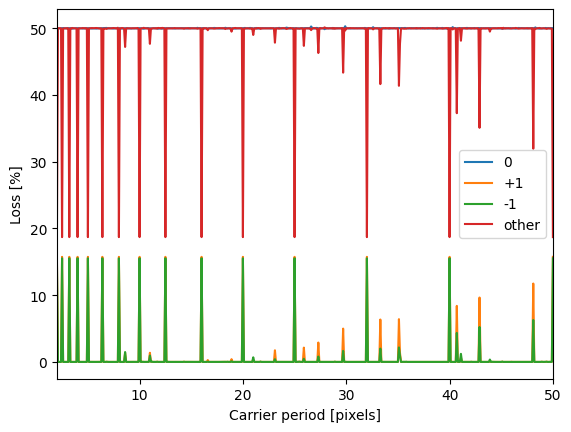

In [277]:
plt.plot(periods, loss0, label='0')
plt.plot(periods, loss1, label='+1')
plt.plot(periods, lossmin1, label='-1')
plt.plot(periods, lossother, label='other')
plt.legend()
plt.xlabel('Carrier period [pixels]')
plt.ylabel('Loss [%]')
plt.xlim(2, 50)
plt.show()

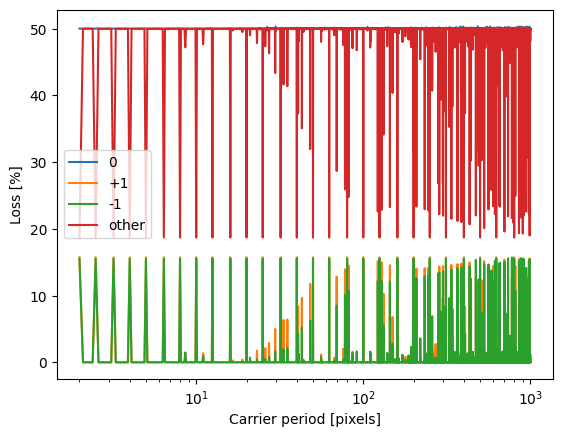

In [271]:
plt.semilogx(periods, loss0, label='0')
plt.semilogx(periods, loss1, label='+1')
plt.semilogx(periods, lossmin1, label='-1')
plt.semilogx(periods, lossother, label='other')
plt.legend()
plt.xlabel('Carrier period [pixels]')
plt.ylabel('Loss [%]')
#plt.xlim(165, 185)
plt.show()

In [274]:
print(np.max(lossmin1))
periods[np.argmax(lossmin1[:100])]

15.723977705126888


np.float64(2.0)

In [ ]:
pitch

1e-05